In [1]:
!pip install shap xgboost

In [2]:
!pip install plotly

In [3]:
#import libraries

import xgboost
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

#print the JS visualization code to notebook
shap.initjs()

In [4]:
#Import dataset

X,y=shap.datasets.adult()
X_display, y_display=shap.datasets.adult(display=True)

In [5]:
X_display.head()
#

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


In [6]:
print(X_display.shape, y_display.shape)

(32561, 12) (32561,)


In [7]:
y_display

array([False, False, False, ..., False, False,  True])

In [8]:
X

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4,12.0,2,13,5,4,0,0.0,0.0,38.0,39
32557,40.0,4,9.0,2,7,4,4,1,0.0,0.0,40.0,39
32558,58.0,4,9.0,6,1,1,4,0,0.0,0.0,40.0,39
32559,22.0,4,9.0,4,1,3,4,1,0.0,0.0,20.0,39


In [9]:
#Create test-train split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=7)
d_train=xgboost.DMatrix(X_train, label=y_train)
d_test=xgboost.DMatrix(X_test, label=y_test)

In [10]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [11]:
params={
    'eta':0.01,
    "objective":"binary:logistic",
    "subsample":0.5,
    "base_score":np.mean(y_train),
    "eval_metric":"logloss",

}

model=xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54666
[100]	test-logloss:0.36390
[200]	test-logloss:0.31754
[300]	test-logloss:0.30058
[400]	test-logloss:0.29155
[500]	test-logloss:0.28652
[600]	test-logloss:0.28343
[700]	test-logloss:0.28173
[800]	test-logloss:0.28058
[900]	test-logloss:0.27976
[1000]	test-logloss:0.27924
[1100]	test-logloss:0.27893
[1200]	test-logloss:0.27878
[1208]	test-logloss:0.27876


In [12]:
#Print accuracy
from sklearn.metrics import accuracy_score

#Make predictions
y_pred_prob=model.predict(d_test)
y_pred=(y_pred_prob>0.5).astype(int)

#Caclulate accuracy
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 87.53%


<function matplotlib.pyplot.show(close=None, block=None)>

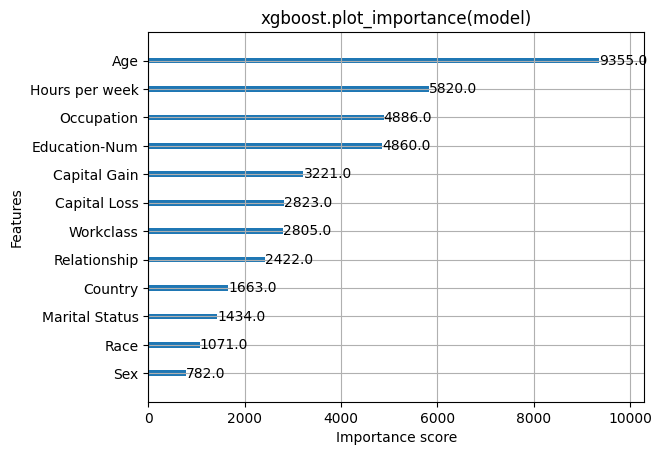

In [13]:
xgboost.plot_importance(model)
plt.title("xgboost.plot_importance(model)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

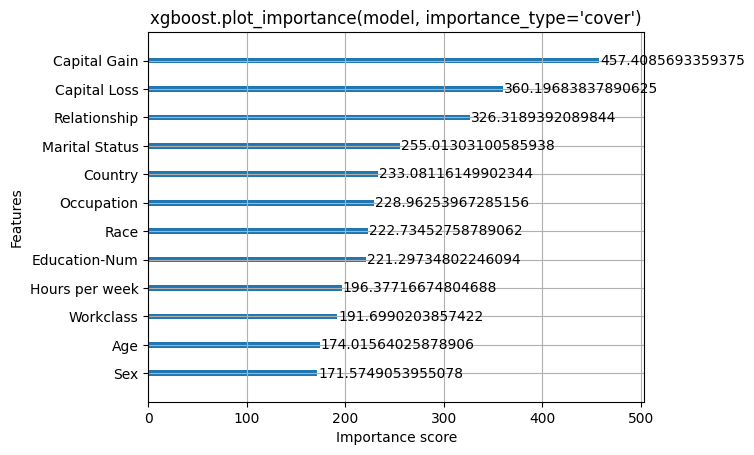

In [14]:
xgboost.plot_importance(model, importance_type='cover')
plt.title("xgboost.plot_importance(model, importance_type='cover')")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

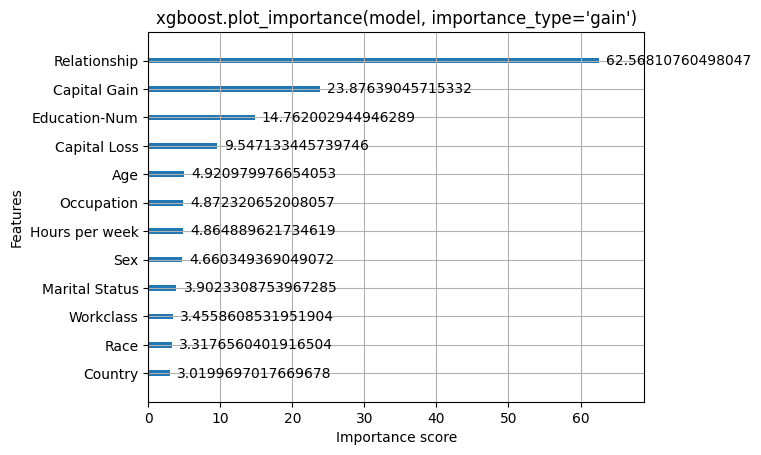

In [15]:
#Gain feature

xgboost.plot_importance(model, importance_type='gain')
plt.title("xgboost.plot_importance(model, importance_type='gain')")
plt.show

SHAP explainer

In [16]:
explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(X)

SHAP force plot

In [18]:
import plotly.io as pio

#Set the default renderer for Plotly to colab
pio.renderers.default='colab'

#print the JS visualization code to the notebook
shap.initjs() #Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[0,:], X_display.iloc[0,:])

In [19]:
#Set the default renderer for Plotly to 'colab

pio.renderers.default='colab'

#print the JS visualization code to the notebook

shap.initjs()

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

SHAP summary plot

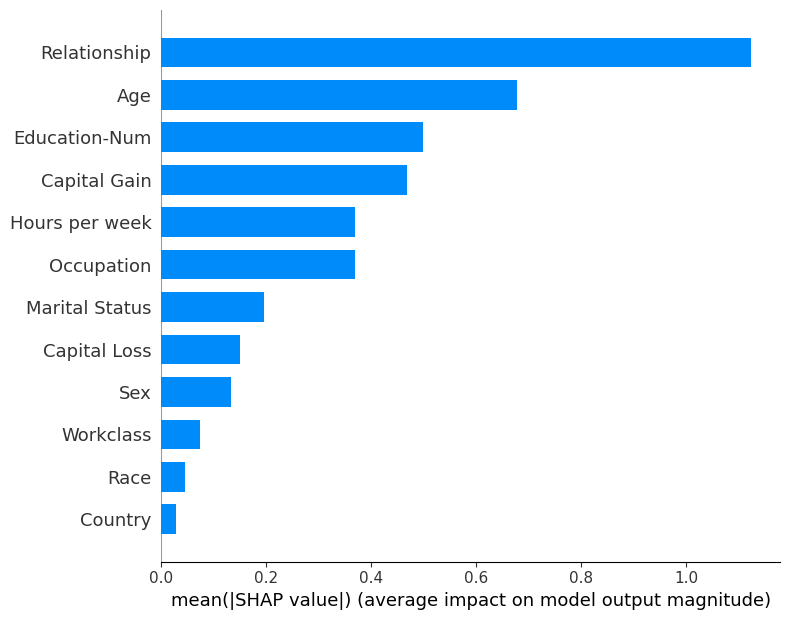

In [20]:
shap.summary_plot(shap_values, X_display, plot_type='bar')

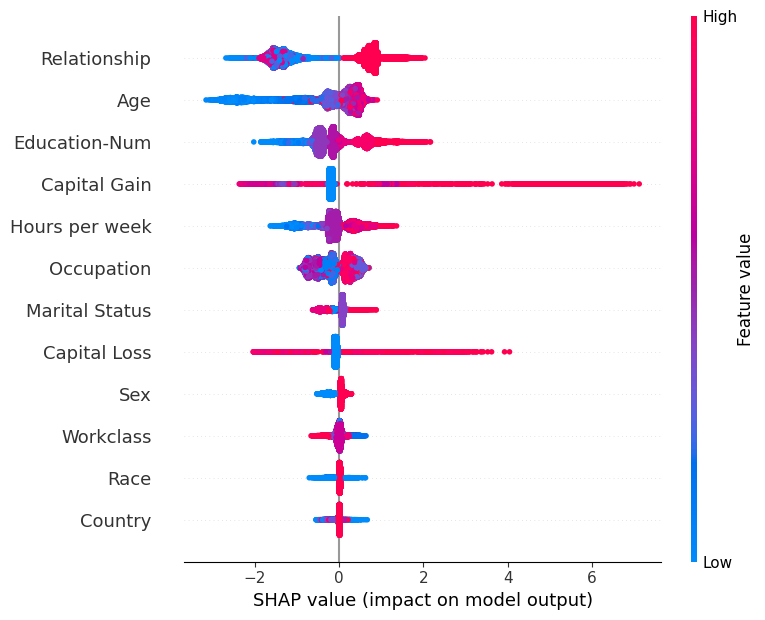

In [21]:
shap.summary_plot(shap_values, X)

SHAP dependence plot

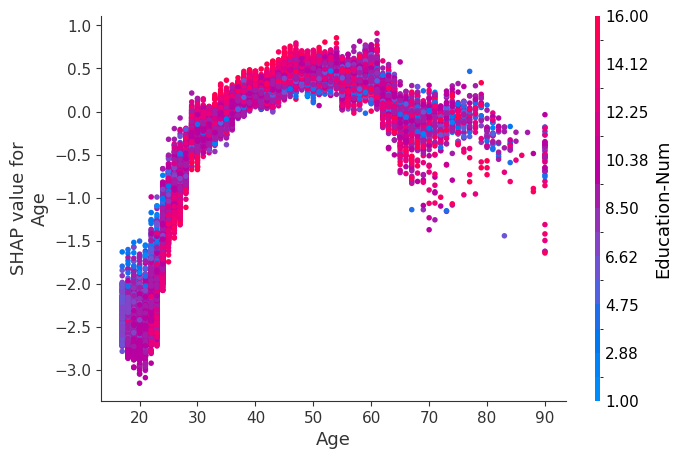

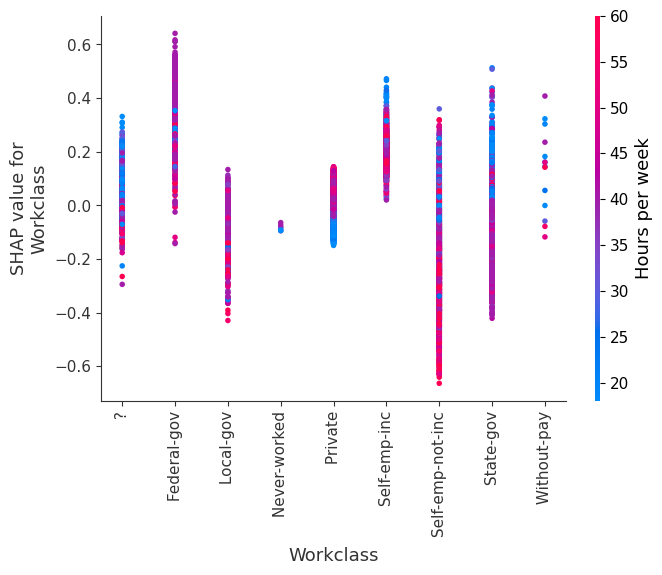

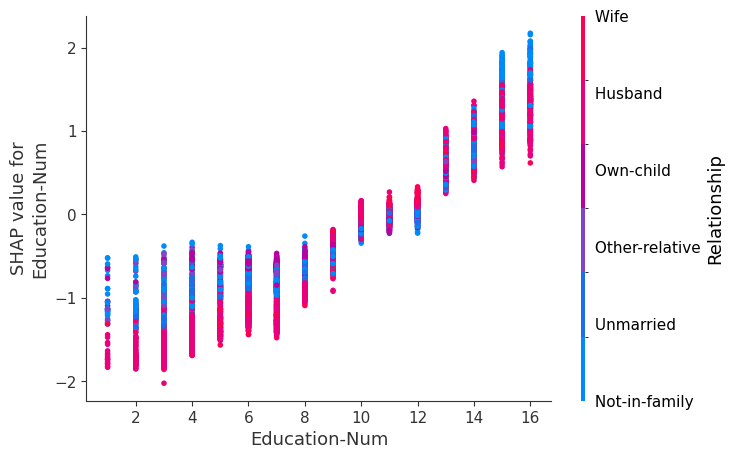

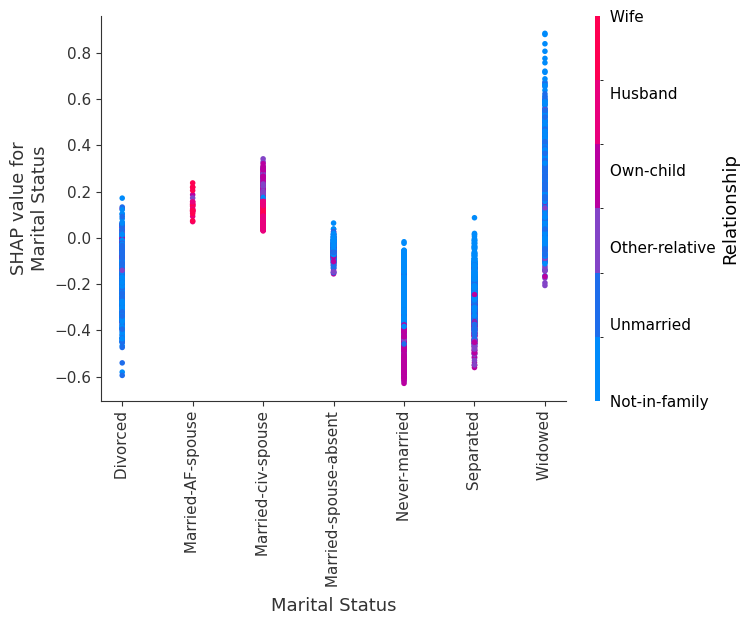

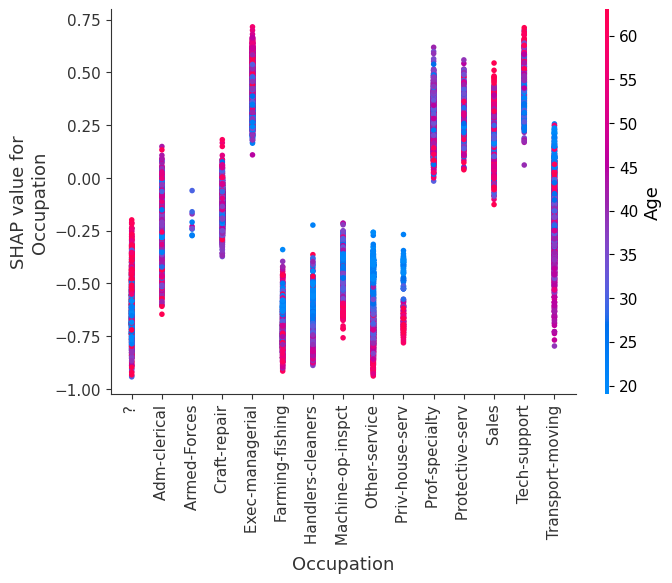

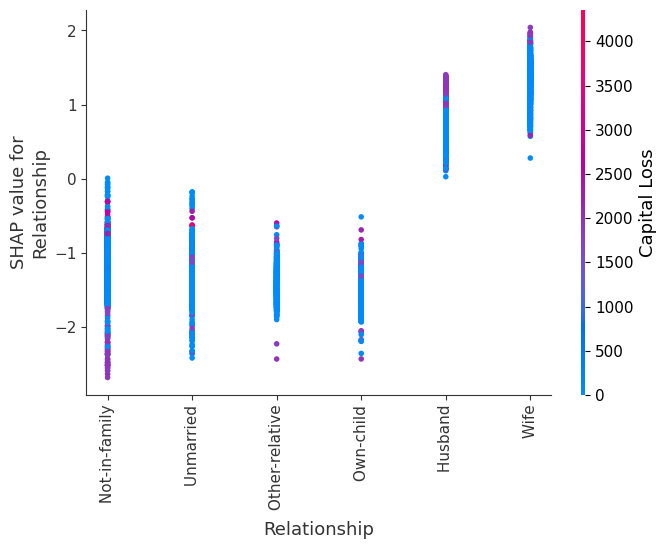

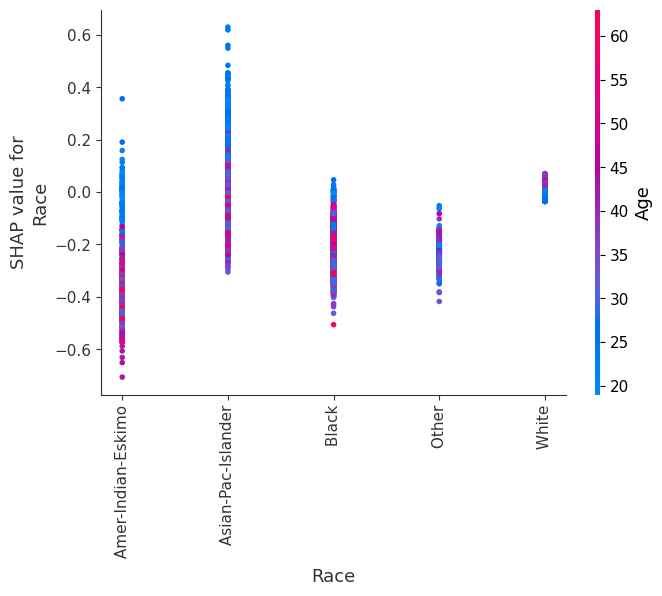

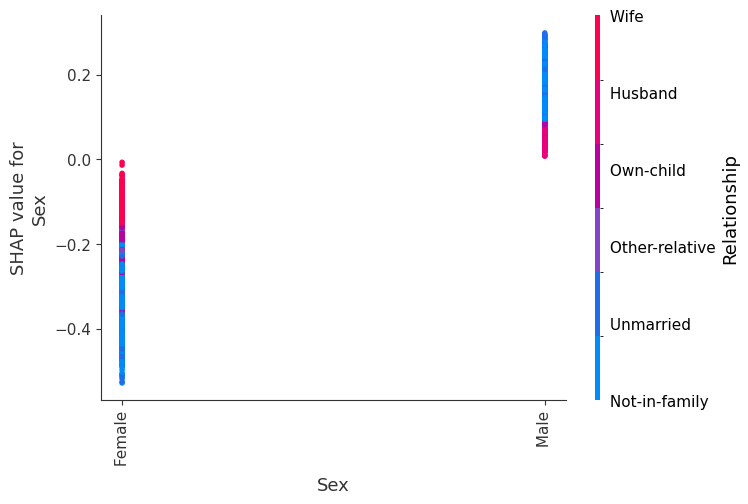

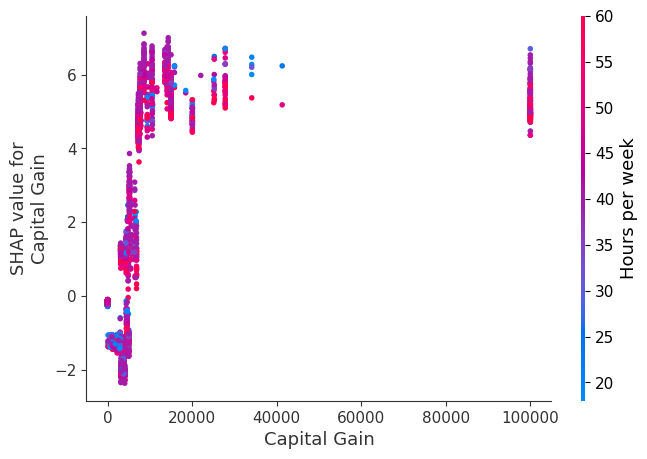

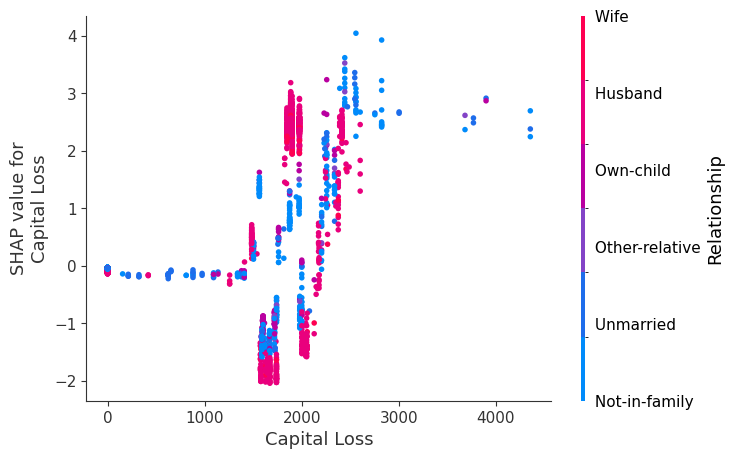

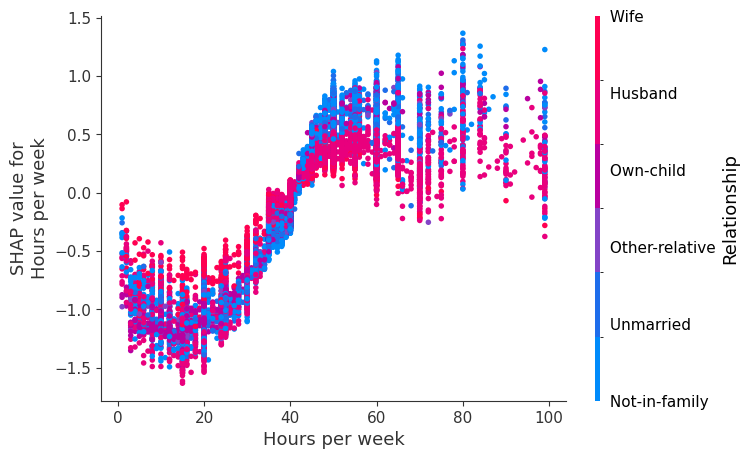

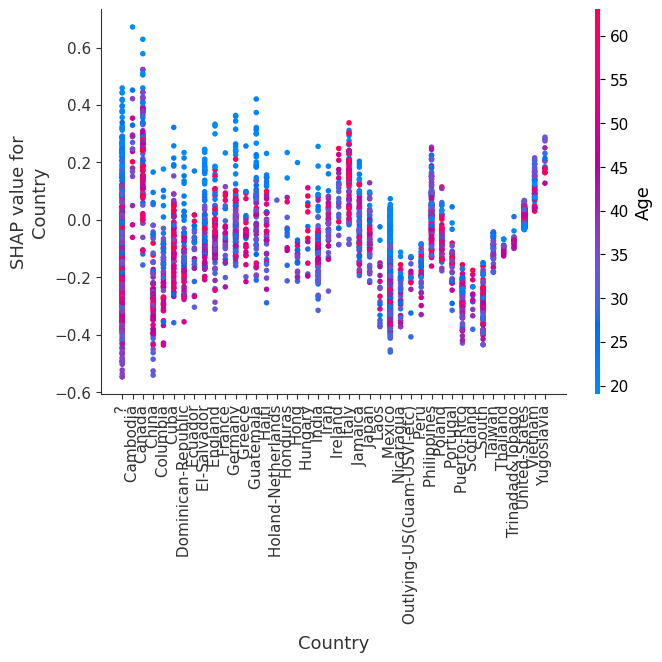

In [22]:
for name in X_train.columns:
  shap.dependence_plot(name, shap_values, X, display_features=X_display)